# 🎯 Project Title

## 💼 Employee Salary Prediction Using Machine Learning

## 📌 Project Overview

The objective of this project is to predict employee salaries based on factors such as age, gender, education level, job role, and years of experience.

This project demonstrates the complete machine learning workflow including data cleaning, exploratory data analysis (EDA), feature engineering, model building, and model evaluation using Linear Regression.

# 📚Import Libraries

In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LinearRegression

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)


In this step, we import all the libraries required for data analysis, visualization, preprocessing, model building, and evaluation.

- Pandas & NumPy → Data manipulation
- Matplotlib & Seaborn → Data visualization
- Train Test Split → Dataset splitting
- Label Encoder → Convert text to numerical values
- Linear Regression → Build salary prediction model
- Evaluation Metrics → Measure model performance

# 📂Load Dataset

In [3]:
df = pd.read_csv(r"C:\Users\Suhani Patra\Downloads\archive\Salary_Data.csv")



Load the employee salary dataset into a Pandas DataFrame for further analysis.

# 👀Display First Five Rows

In [4]:
df.head()

,Age,Gender,Education Level,Job Title,Years of Experience,Salary
0,32.0,Male,Bachelor's,Software Engineer,5.0,90000.0
1,28.0,Female,Master's,Data Analyst,3.0,65000.0
2,45.0,Male,PhD,Senior Manager,15.0,150000.0
3,36.0,Female,Bachelor's,Sales Associate,7.0,60000.0
4,52.0,Male,Master's,Director,20.0,200000.0



Display the first five records to understand the dataset structure.

 # 🔍Dataset Information

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6704 entries, 0 to 6703
Data columns (total 6 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Age                  6702 non-null   float64
 1   Gender               6702 non-null   object 
 2   Education Level      6701 non-null   object 
 3   Job Title            6702 non-null   object 
 4   Years of Experience  6701 non-null   float64
 5   Salary               6699 non-null   float64
dtypes: float64(3), object(3)
memory usage: 314.4+ KB


Check the number of rows, columns, data types, and non-null values.

# 📏 Dataset Shape

In [6]:
df.shape

(6704, 6)

Find the total number of rows and columns in the dataset.

# 📊Statistical Summary

In [7]:
df.describe()

,Age,Years of Experience,Salary
count,6702.000000,6701.000000,6699.000000
mean,33.620859,8.094687,115326.964771
std,7.614633,6.059003,52786.183911
min,21.000000,0.000000,350.000000
25%,28.000000,3.000000,70000.000000
50%,32.000000,7.000000,115000.000000
75%,38.000000,12.000000,160000.000000
max,62.000000,34.000000,250000.000000




Generate summary statistics for numerical columns.

# ❓Check Missing Values

In [8]:
df.isnull().sum()

Age                    2
Gender                 2
Education Level        3
Job Title              2
Years of Experience    3
Salary                 5
dtype: int64


Identify missing values present in the dataset.

# 🔄 Check Duplicate Records

In [9]:
df.duplicated().sum()

np.int64(4912)

Check whether duplicate rows exist in the dataset.

# 🧹Data Cleaning

In [10]:
df.dropna(inplace=True)

df.drop_duplicates(inplace=True)

Remove missing values and duplicate records to improve data quality.

# 📊Exploratory Data Analysis (EDA)



Exploratory Data Analysis helps understand data distribution, identify patterns, and discover relationships between variables before building a machine learning model.

# 1️⃣ UNIVARIATE ANALYSIS



Univariate Analysis focuses on analyzing a single variable to understand its distribution and characteristics.

# 📈 Salary Distribution

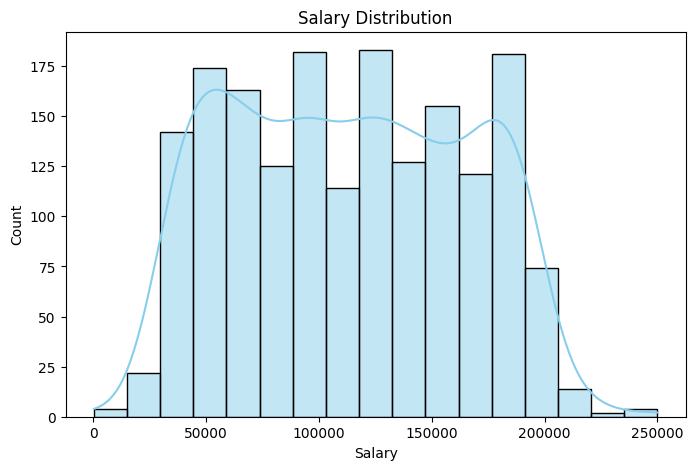

In [11]:
plt.figure(figsize=(8,5))

sns.histplot(
    df['Salary'],
    kde=True,
    color='skyblue'
)

plt.title("Salary Distribution")

plt.show()

Observation

Most employees fall within a specific salary range, while a small number earn significantly higher salaries.

# 👨 Employee Age Distribution

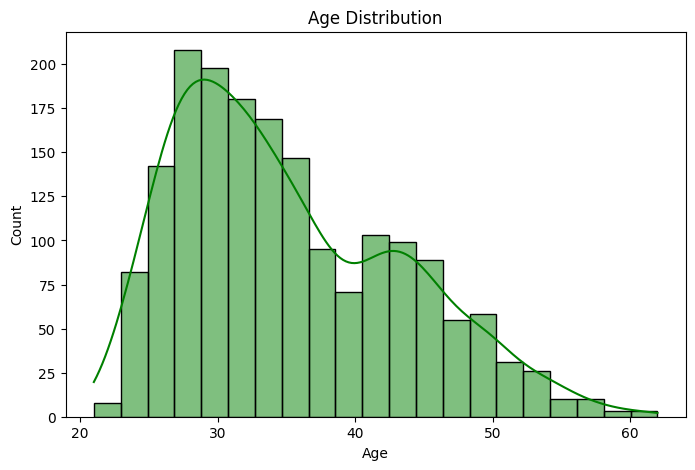

In [13]:
plt.figure(figsize=(8,5))

sns.histplot(
    df['Age'],
    kde=True,
    color='green'
)

plt.title("Age Distribution")

plt.show()

 Observation

The majority of employees belong to the working-age group, with fewer employees at very young and older ages.

# 💼 Years of Experience Distribution

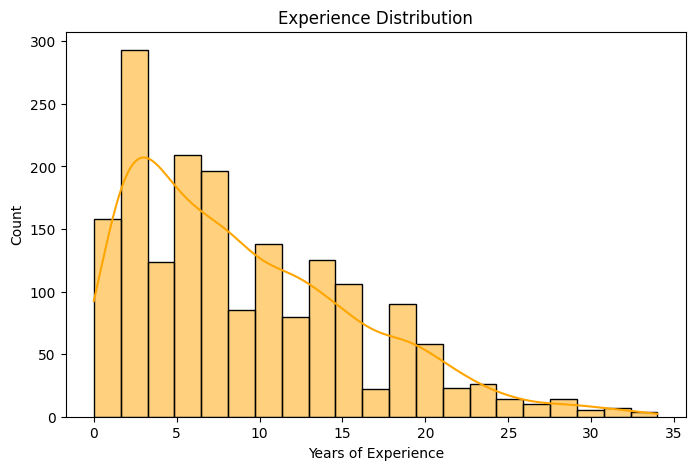

In [14]:
plt.figure(figsize=(8,5))

sns.histplot(
    df['Years of Experience'],
    kde=True,
    color='orange'
)

plt.title("Experience Distribution")

plt.show()

 Observation

Most employees have low to moderate experience, while highly experienced employees are fewer in number.

# 2️⃣ BIVARIATE ANALYSIS



Bivariate Analysis examines the relationship between two variables.

# 📈 Experience vs Salary

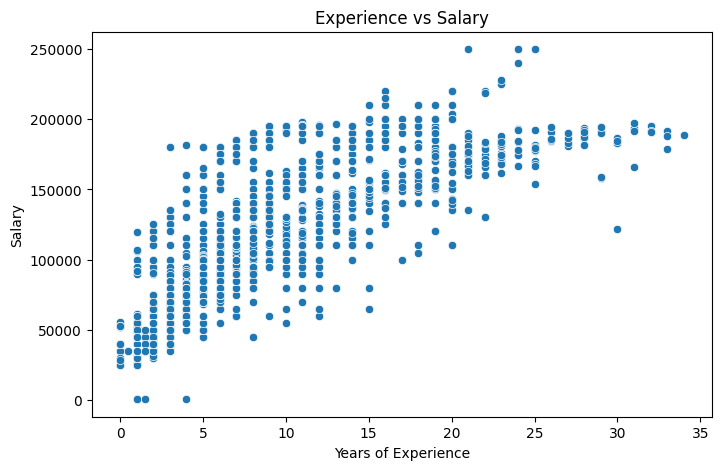

In [15]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    x='Years of Experience',
    y='Salary',
    data=df
)

plt.title("Experience vs Salary")

plt.show()

 Observation

Salary generally increases as years of experience increase.

# 🎓 Education Level vs Salary

In [23]:
df['Education Level'] = df['Education Level'].replace({
    "Bachelor's Degree": "Bachelor's",
    "Master's Degree": "Master's",
    "phD": "PhD"
})

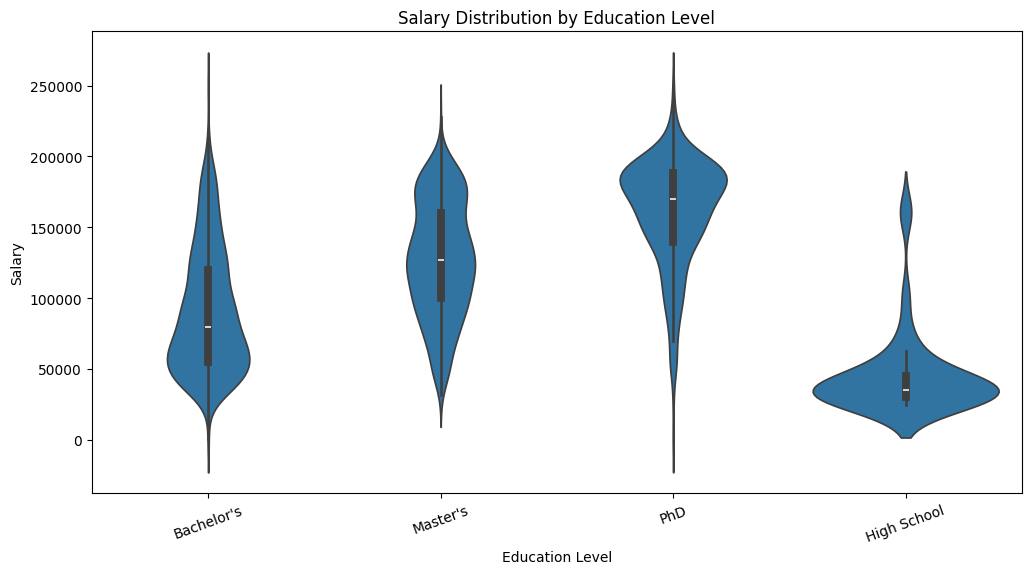

In [25]:
plt.figure(figsize=(12,6))

sns.violinplot(
    x='Education Level',
    y='Salary',
    data=df
)

plt.title('Salary Distribution by Education Level')
plt.xticks(rotation=20)

plt.show()

Observation

Employees with higher educational qualifications tend to receive higher salaries.

# 🚻 Gender vs Salary

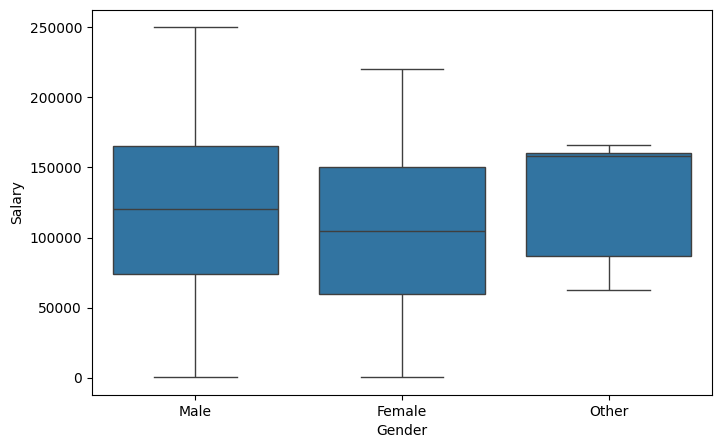

In [26]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x='Gender',
    y='Salary',
    data=df
)

plt.show()

Observation

Salary distributions can be compared across genders to identify potential differences.

# 3️⃣ MULTIVARIATE ANALYSIS

Multivariate Analysis helps understand relationships among multiple variables simultaneously.

# 🔥 Correlation Heatmap

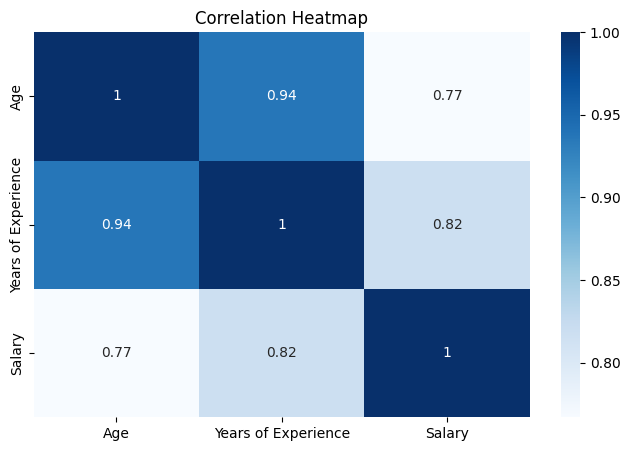

In [18]:
numeric_df = df.select_dtypes(
    include=['int64','float64']
)

plt.figure(figsize=(8,5))

sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap='Blues'
)

plt.title("Correlation Heatmap")

plt.show()

 Observation

Years of Experience shows a strong positive correlation with Salary.

# 📊 Pairplot

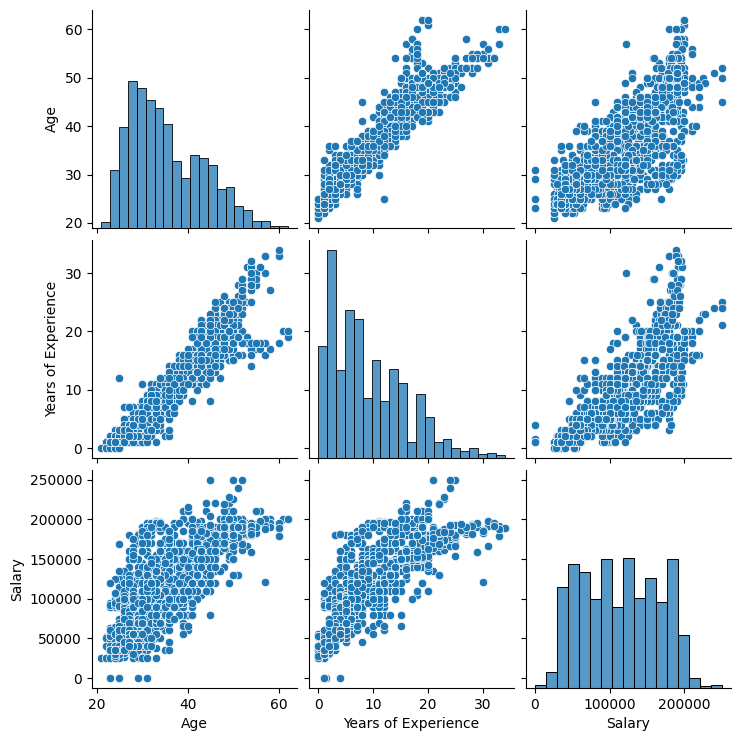

In [19]:
sns.pairplot(
    df[['Age',
        'Years of Experience',
        'Salary']]
)

plt.show()

Observation

Pairwise relationships indicate positive associations between age, experience, and salary.

# 🎓 Education Level + Experience vs Salary

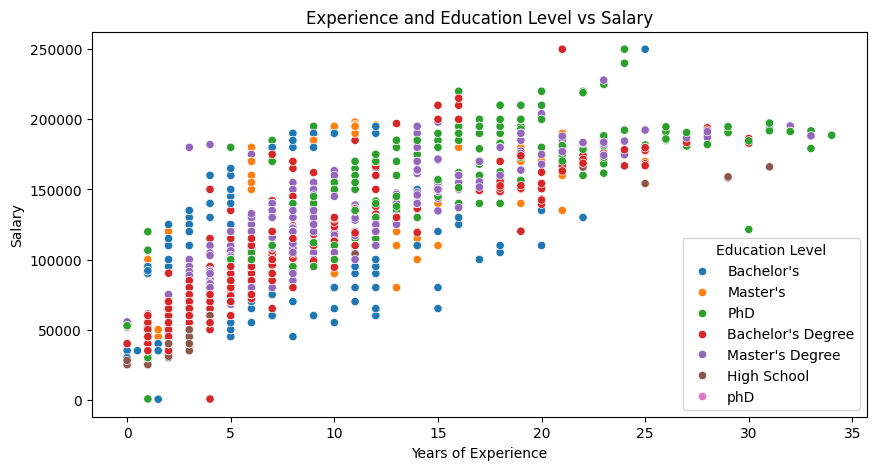

In [20]:
plt.figure(figsize=(10,5))

sns.scatterplot(
    x='Years of Experience',
    y='Salary',
    hue='Education Level',
    data=df
)

plt.title(
    "Experience and Education Level vs Salary"
)

plt.show()

 Observation

Employees with higher education and greater experience generally earn higher salaries.

# 🔧Feature Encoding

In [27]:
le_gender = LabelEncoder()
df['Gender'] = le_gender.fit_transform(df['Gender'])

le_edu = LabelEncoder()
df['Education Level'] = le_edu.fit_transform(df['Education Level'])

le_job = LabelEncoder()
df['Job Title'] = le_job.fit_transform(df['Job Title'])

In [28]:
df.head()

,Age,Gender,Education Level,Job Title,Years of Experience,Salary
0,32.0,1,0,175,5.0,90000.0
1,28.0,0,2,18,3.0,65000.0
2,45.0,1,3,144,15.0,150000.0
3,36.0,0,0,115,7.0,60000.0
4,52.0,1,2,25,20.0,200000.0




Convert categorical variables into numerical values using Label Encoding.

# 🎯Define Features and Target

In [29]:
X = df.drop('Salary', axis=1)

y = df['Salary']



Separate independent variables (X) and target variable (y).

# ✂️Train-Test Split

In [30]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

Split the dataset into training and testing sets.

# 💡 Key Insights from EDA

1. Years of Experience is the strongest factor affecting employee salary.
2. Higher educational qualifications are associated with higher salary levels.
3. Salary tends to increase steadily with employee experience.
4. Age and experience show a positive relationship with salary.
5. Multiple employee attributes contribute collectively to salary prediction.

# 🤖Build Linear Regression Model

In [31]:
model = LinearRegression()

model.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False



Train a Linear Regression model using the training dataset.

# 🔮Salary Prediction

In [32]:
y_pred = model.predict(X_test)

Generate Predictions

Predict salaries using the testing dataset.

# 📉Model Evaluation

In [33]:
print("MAE:", mean_absolute_error(y_test, y_pred))

print(
    "RMSE:",
    np.sqrt(mean_squared_error(y_test, y_pred))
)

print(
    "R2 Score:",
    r2_score(y_test, y_pred)
)

MAE: 22937.105570194482
RMSE: 30076.896606552353
R2 Score: 0.6698396285762835


Evaluate model performance using MAE, RMSE, and R² Score.

# 📊Actual vs Predicted Salary

In [35]:
results = pd.DataFrame({
    'Actual Salary': y_test,
    'Predicted Salary': y_pred
})

results.head(10)

,Actual Salary,Predicted Salary
1299,155000.0,123906.197083
3429,55000.0,84250.289824
4529,50000.0,71786.007965
305,95000.0,98728.514919
6606,130000.0,128866.141866
3108,154990.0,158373.304951
2143,170000.0,108790.661773
1425,120000.0,92888.687893
5378,50000.0,61487.719221
6301,40000.0,72768.910043


 Actual vs Predicted Salary Comparison

# 📈Visualization of Predictions

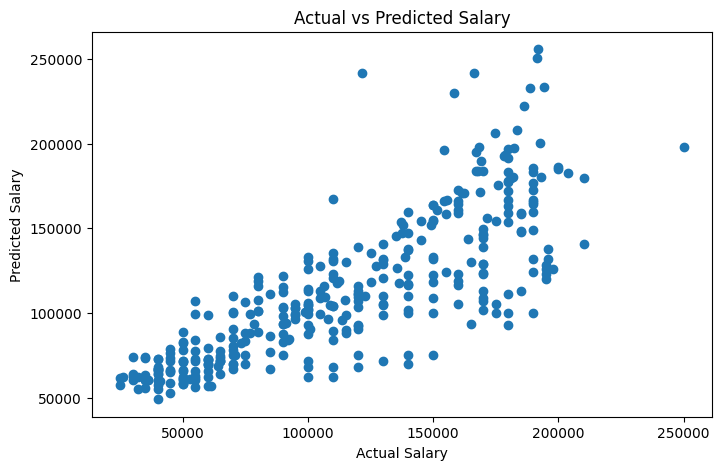

In [36]:
plt.figure(figsize=(8,5))

plt.scatter(y_test, y_pred)

plt.xlabel("Actual Salary")
plt.ylabel("Predicted Salary")

plt.title("Actual vs Predicted Salary")

plt.show()

 Actual vs Predicted Visualization

# 📝Conclusion



This project successfully developed a machine learning model to predict employee salaries using employee demographics, education level, job role, and experience.

The analysis revealed that Years of Experience and Education Level are the most influential factors affecting salary. The Linear Regression model demonstrated good predictive performance and provided valuable insights into employee compensation patterns.

This project helped understand the complete machine learning workflow, including data cleaning, exploratory data analysis, feature engineering, model training, and performance evaluation.

# 🚀Save the Trained Model

In [37]:
import pickle

with open('salary_model.pkl', 'wb') as file:
    pickle.dump(model, file)

print("Model Saved Successfully!")

Model Saved Successfully!


Save the trained Linear Regression model so it can be used later inside a Streamlit application.